# 04 — Mô hình Lee-Carter (baseline)

Trước khi chạy notebook này, cần fit mô hình bằng R (chỉ cần chạy một lần, hoặc
lại mỗi khi `data/processed/wpp_vnm/Dxt_total.csv`/`Ext_total.csv` thay đổi):

```bash
Rscript R/02a_fit_lc.R
```

Script này fit LC trên series `total` và ghi tham số ra
`results/wpp_vnm/params_lc_*.csv` + residuals — notebook 04 chỉ đọc và
trực quan hoá phần LC (`params_lc_age.csv`, `params_lc_kt.csv`,
`residuals_lc.csv`). Trình bày: ax, bx, kt; kiểm tra giả định random-walk-with-drift
của kt; residual heatmap; diễn giải tham số cho dữ liệu Việt Nam.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import numpy as np
import pandas as pd
from src.config import load_params, results_dir

cfg = load_params()

params_age = pd.read_csv(results_dir("wpp_vnm") / "params_lc_age.csv")
params_kt = pd.read_csv(results_dir("wpp_vnm") / "params_lc_kt.csv")
kt = params_kt.set_index("year")["kt"]

residuals_lc = pd.read_csv(results_dir("wpp_vnm") / "residuals_lc.csv", index_col=0)
residuals_lc.columns = residuals_lc.columns.astype(int)
residuals_lc.index = residuals_lc.index.astype(int)

params_age.shape, kt.shape, residuals_lc.shape

((91, 3), (19,), (91, 19))

## Tham số ax, bx, kt

Mô hình Lee-Carter: $\log m_{x,t} = a_x + b_x k_t$, với ràng buộc chuẩn hoá
$\sum_x b_x = 1$, $\sum_t k_t = 0$ (StMoMo dùng ràng buộc này mặc định).

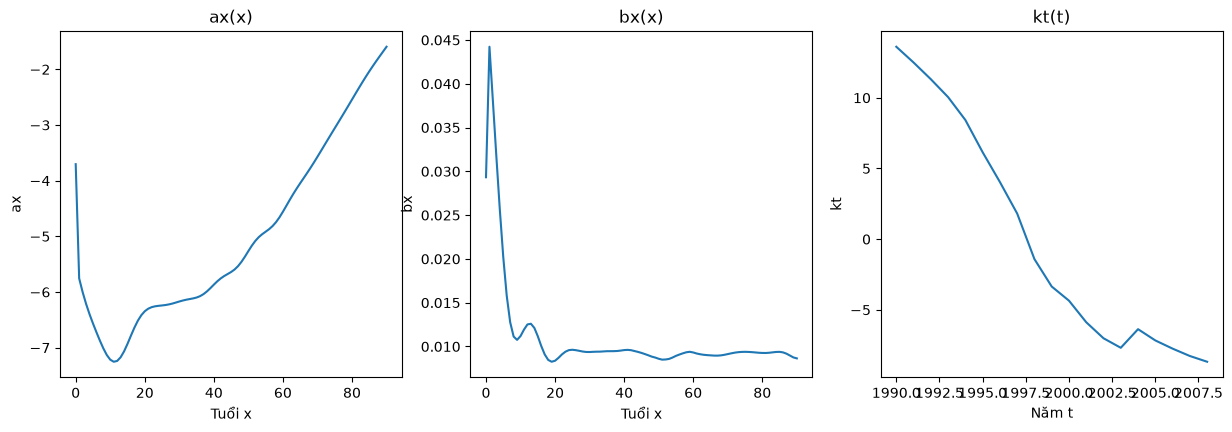

In [3]:
from src.visualization.plots import plot_lc_params

plot_lc_params(params_age, kt, name="lc_params_total")

**Nhận xét:**

- **ax(x)** tái hiện đúng hình "checkmark" đã thấy ở log mx thô (notebook 02):
  thấp nhất ở tuổi 11 (ax ≈ −7.25, đáy tử vong tuổi thiếu niên), cao nhất ở
  tuổi 90 (ax ≈ −1.59). Hợp lý vì ax chính là log mx trung bình theo thời gian
  ở từng tuổi, tính trên cửa sổ fit 1990-2008.
- **bx(x)** đo mức độ mỗi tuổi phản ứng với xu hướng chung kt — **cao nhất ở
  đúng tuổi 1** (bx ≈ 0.0442, gấp ~4 lần mức trung bình 1/91≈0.011), rồi
  giảm dần; thấp nhất ở tuổi 19 (bx ≈ 0.0083), tuổi 90 gần như ngang mức đó
  (bx ≈ 0.0086). Tuổi 1 nhạy nhất với kt nghĩa
  là mx tuổi 1 biến động (cải thiện) nhanh nhất theo thời gian trong toàn bộ
  dải tuổi — đáng chú ý vì đây đúng là tuổi từng được flag có ngoại lệ tỷ số
  nam/nữ ở notebook 02; bx cao bất thường ở đây có thể một phần phản ánh cùng
  nguồn artifact ước lượng của UN cho tử vong trẻ em, chứ không hẳn thuần tuý
  là tín hiệu cải thiện y tế.
- **kt(t)** giảm gần như tuyến tính từ **13.61 (1990) xuống −8.67 (2008)**,
  độ dốc trung bình ≈ **−1.38/năm** — vì bx > 0 với mọi tuổi, kt giảm đồng
  nghĩa mx giảm ở mọi tuổi cùng chiều, đúng với xu hướng cải thiện tử vong
  chung đã thấy xuyên suốt notebook 02. Lưu ý: cửa sổ fit hiện tại (1990-2008,
  19 năm) hẹp hơn nhiều so với toàn bộ dữ liệu thu thập được (1955-2023). Cửa sổ
  này theo thiết kế nhánh B (`docs/ban-do-tri-thuc-luan-van-du-bao-tu-vong.md`, Mục 12.2): khớp trên WPP 1990-2008, dự
  báo 2009-2024 rồi kiểm chứng tại các bảng sống TCTK 2009, 2014, 2019, 2024
  (tầm dự báo 1, 6, 11, 16 năm). Mốc bắt đầu 1990 cũng nằm sau điểm gãy cấu
  trúc 1974 tìm thấy ở notebook 02 (`fitting.years` trong `config/params.yaml`).

## Kiểm tra giả định random-walk-with-drift cho kt

`config/params.yaml` chọn RWD (`forecast.kt_model: "rwd"`) để dự báo kt ở
notebook 07 — RWD hợp lý khi kt là bước ngẫu nhiên (chuỗi mức, non-stationary)
còn sai phân bậc 1 của kt là stationary. Kiểm tra bằng ADF test (Augmented
Dickey-Fuller) trên cả kt gốc và diff(kt).

In [4]:
from statsmodels.tsa.stattools import adfuller

dkt = kt.diff().dropna()
stat_level, p_level, *_ = adfuller(kt)
stat_diff, p_diff, *_ = adfuller(dkt)

pd.DataFrame({
    "chuỗi": ["kt (gốc)", "diff(kt)"],
    "ADF statistic": [round(stat_level, 3), round(stat_diff, 3)],
    "p-value": [round(p_level, 4), round(p_diff, 6)],
    "drift trung bình diff": [np.nan, round(dkt.mean(), 3)],
})

,chuỗi,ADF statistic,p-value,drift trung bình diff
0,kt (gốc),-2.294,0.173800,NaN
1,diff(kt),-1.700,0.431039,-1.238


**Nhận xét:** kt gốc **không bác bỏ** giả thuyết có unit root (p ≈ 0.17 — không
stationary, đúng như kỳ vọng của một random walk), nhưng diff(kt) **cũng không
bác bỏ** giả thuyết đó (p ≈ 0.43), tức ADF trực tiếp trên kt không cung cấp
bằng chứng cho tính dừng của sai phân. Nguyên nhân: cửa sổ fit hiện tại chỉ có
19 năm (1990-2008) → diff(kt) chỉ còn 18 quan sát, ít hơn nhiều so với 68 sai
phân nếu tính trên toàn bộ 1955-2023 - kiểm định ADF gần như không có power
thống kê với cỡ mẫu này. Drift trung bình vẫn âm rõ rệt (≈ −1.24/năm, khớp
hướng với độ dốc tuyến tính ước lượng ở trên).

Vì vậy, bằng chứng **chính** để chọn random-walk-with-drift cho kt trong
`config/params.yaml` nên dựa vào kiểm định ADF trên chỉ số $\bar m_t$ (trung
bình log mx theo tuổi 0-90) tính trên toàn bộ 1955-2023 ở notebook 02 - kiểm
định đó có 68 sai phân (nhiều hơn hẳn 18 sai phân ở đây) nên có power cao hơn,
và cho kết quả rõ ràng hơn (p ≈ 0.0002 cho diff, xem notebook 02). Kết quả ADF
trực tiếp trên kt ở đây nên được xem là bằng chứng **bổ sung, yếu hơn**, không
phải bằng chứng chính - đây cũng là một hạn chế cần nêu trong luận văn: cửa sổ
fit 19 năm là quá ngắn để kiểm định vững chắc tính chất chuỗi thời gian của kt
(cái giá của thiết kế nhánh B, đổi lại có các điểm kiểm chứng ngoài mẫu độc lập).

## Residual heatmap — kiểm tra hiệu ứng thế hệ còn sót lại

Deviance residual thật của mô hình LC đã fit (khác với phần dư "naive" tuổi+năm
dùng để thăm dò ở notebook 02) — nếu còn vệt chéo hệ thống theo cohort, đó là
bằng chứng LC (không có cấu phần cohort) bỏ sót cấu trúc thật trong dữ liệu,
lý do chính để chuyển sang Renshaw-Haberman ở notebook 05.

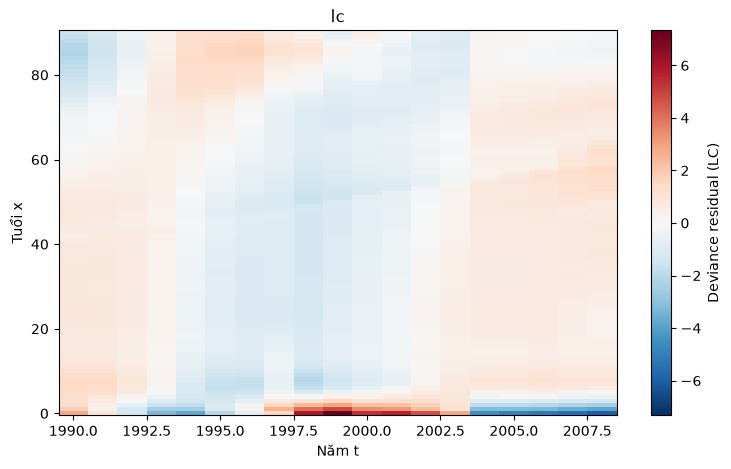

In [5]:
from src.visualization.plots import plot_residual_heatmap

plot_residual_heatmap(residuals_lc, model="lc", ylabel="Deviance residual (LC)")

In [6]:
from src.evaluation.cohort import cohort_mean_residual

# Mỗi cohort có tối đa bằng số năm fit quan sát (fitting.years), nên ngưỡng min_obs
# cố định sẽ rỗng khi cửa sổ ngắn lại. Dùng ~2/3 số năm fit để loại cohort ở rìa mà
# vẫn giữ đủ dữ liệu để tính.
min_obs = int(2 / 3 * residuals_lc.shape[1])
cohort_resid_lc = cohort_mean_residual(residuals_lc, min_obs=min_obs)
print(f"Khoảng biến thiên residual trung bình theo cohort (n>={min_obs}):",
      round(cohort_resid_lc.min(), 3), "->", round(cohort_resid_lc.max(), 3))
cohort_resid_lc.sort_values(ascending=False).head(5).round(3).to_frame("mean_residual")

Khoảng biến thiên residual trung bình theo cohort (n>=12): -0.574 -> 1.326


,mean_residual
1997,1.326
1996,0.869
1995,0.355
1911,0.348
1912,0.280


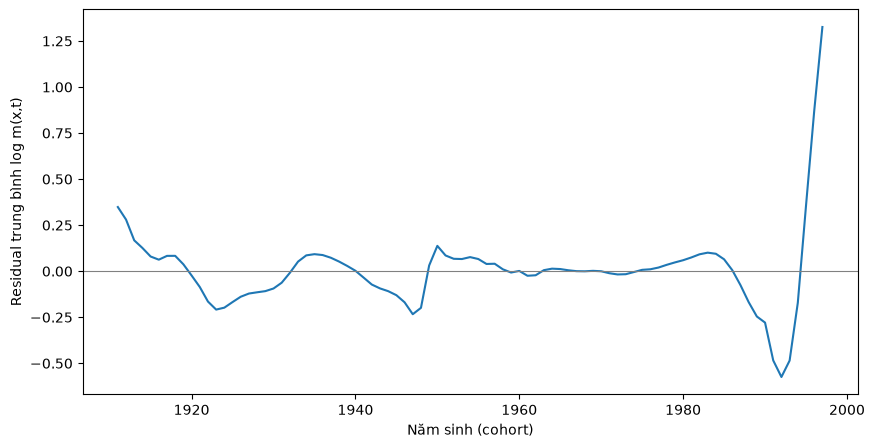

In [7]:
from src.visualization.plots import plot_cohort_mean_residual

plot_cohort_mean_residual(cohort_resid_lc, name="lc_cohort_mean_residual")

**Nhận xét:**

- Deviance residual trung bình theo cohort (n≥12 ô tuổi-năm, ~2/3 số năm fit)
  dao động từ **−0.57 (cohort 1992)** đến **+1.33 (cohort 1997)**. Cả hai cohort
  cực trị đều nằm sát **biên** của cửa sổ quan sát 1990-2008 (19 năm): cohort
  1992 chỉ quan sát được ở tuổi 0-16, cohort 1997 chỉ ở tuổi 0-11 và vừa đủ
  ngưỡng 12 quan sát. Tức là các giá trị cực trị này đến từ vùng tuổi nhỏ
  (nơi bx lớn nhất, và tuổi 1 từng bị nghi artifact ước lượng ở notebook 02),
  không phải từ một thế hệ được theo dõi qua nhiều tuổi. Đây là dấu hiệu của vấn đề nhận dạng tuổi-năm-thế hệ (age-period-
  cohort identification problem) khi cửa sổ thời gian ngắn so với dải tuổi
  fit, chứ không phải một mô thức cohort có cấu trúc rõ ràng.
- **Không nên dùng kết quả này để kết luận về hình dạng thật của hiệu ứng thế
  hệ.** So với "gò" ở notebook 02 (đỉnh dương ở cohort 1950-1954, tính trên
  toàn bộ 1955-2023 bằng phân rã naive, giả định ngầm $b_x=1$): hai phép tính
  vừa khác phương pháp (naive vs. deviance residual thật của LC) vừa khác hẳn
  cửa sổ quan sát (69 năm vs. 19 năm), nên không so sánh trực tiếp được nữa.
  Kết luận chắc chắn về hiệu ứng thế hệ tại Việt Nam cần đợi ước lượng $\gamma_c$
  chính thức của Renshaw-Haberman (notebook 05) - và ngay cả khi đó, cửa sổ fit
  19 năm vẫn là một hạn chế cần nêu rõ khi diễn giải $\gamma_c$ ở các cohort gần
  biên; hơn nữa với dữ liệu WPP, $\gamma_c$ không nên được diễn giải như dấu vết
  lịch sử (`docs/ban-do-tri-thuc-luan-van-du-bao-tu-vong.md`, Mục 4.2 và 8.2).